In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

In [34]:
data= load_wine()
df=pd.DataFrame(data.data, columns=data.feature_names)

In [35]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [36]:
newdf=df[['alcohol','proline']]

In [37]:
newdf

,alcohol,proline
0,14.23,1065.0
1,13.20,1050.0
2,13.16,1185.0
3,14.37,1480.0
4,13.24,735.0
...,...,...
173,13.71,740.0
174,13.40,750.0
175,13.27,835.0
176,13.17,840.0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(newdf, data.target, test_size=0.2, random_state=42)

In [39]:
X_train.shape, X_test.shape


((142, 2), (36, 2))

# Normalization

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()

In [41]:
scaler.fit(X_train)
X_train_scaled= scaler.transform(X_train)
X_test_scaled= scaler.transform(X_test)

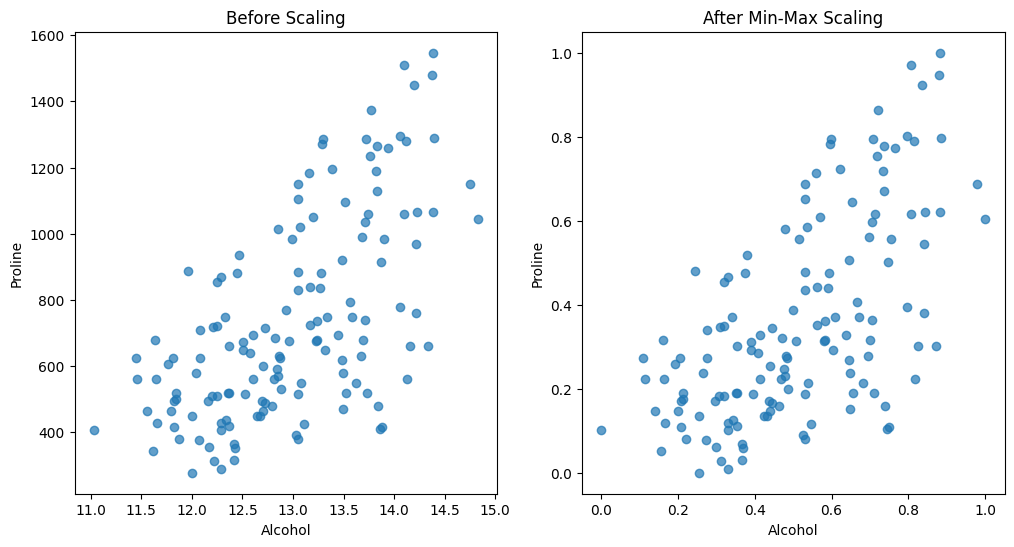

In [42]:
#scatter plot 
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12,6))
ax1.set_title('Before Scaling')
ax1.scatter(X_train['alcohol'], X_train['proline'], alpha=0.7)
ax1.set_xlabel('Alcohol')
ax1.set_ylabel('Proline')  

ax2.set_title('After Min-Max Scaling')
ax2.scatter(X_train_scaled[:,0], X_train_scaled[:,1], alpha=0.7)
ax2.set_xlabel('Alcohol')
ax2.set_ylabel('Proline')  
plt.show()

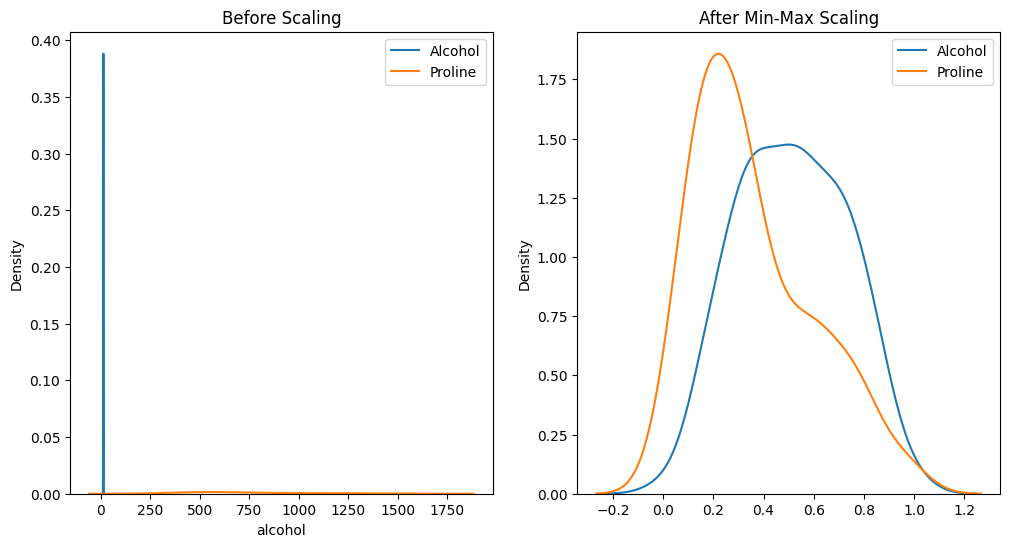

In [43]:
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12,6))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['proline'], ax=ax1, label='Proline')
ax1.legend()
ax2.set_title('After Min-Max Scaling')
sns.kdeplot(X_train_scaled[:,0], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled[:,1], ax=ax2, label='Proline')
ax2.legend()
plt.show()

# Effect of Scaling

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [45]:
model= LogisticRegression()
model.fit(X_train, y_train)
y_pred= model.predict(X_test)
accuracy= accuracy_score(y_test, y_pred)
print(f'Accuracy without scaling: {accuracy:.4f}')

Accuracy without scaling: 0.8889


/Users/kishan/.pyenv/versions/3.11.14/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
model_scaled= LogisticRegression()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled= model_scaled.predict(X_test_scaled)
accuracy_scaled= accuracy_score(y_test, y_pred_scaled)
print(f'Accuracy with Min-Max Scaling: {accuracy_scaled:.4f}')  

Accuracy with Min-Max Scaling: 0.9167
